## CMPE-257, Machine Learning, Summer 2025
## Week 7: Tree-based Methods
In this workbook, you will be exploring decision trees for classification

- decision tree classifier
- random forest classifier
- gradient boosting classifier

In [1]:
# YOUR NAME: Quoc Dung Lam

In [2]:
# loads required modules
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import classification_report
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [3]:
# Loads the "iris_plants_dataset" and displays its description

iris = datasets.load_iris()
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

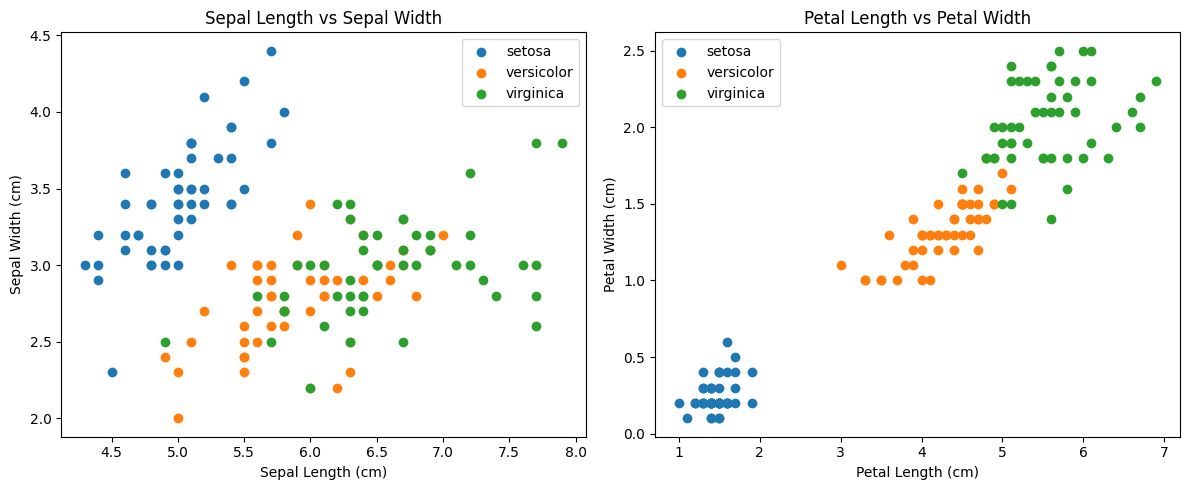

In [4]:
# Excercise #1: generate two cross-plots (sepal lenght vs sepal width, and petal lenght vs petal width)
# and color each data point according to its corresponding class

X = iris.data
y = iris.target
target_names = iris.target_names

# Create a scatter plot for sepal length vs sepal width
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for target in range(len(target_names)):
    plt.scatter(
        X[y == target, 0],  # sepal length
        X[y == target, 1],  # sepal width
        label=target_names[target]
    )
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')
plt.legend()

# Create a scatter plot for petal length vs petal width
plt.subplot(1, 2, 2)
for target in range(len(target_names)):
    plt.scatter(
        X[y == target, 2],  # petal length
        X[y == target, 3],  # petal width
        label=target_names[target]
    )
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Petal Length vs Petal Width')
plt.legend()

plt.tight_layout()
plt.show()



In [5]:
# What are your main observations from exercise #1?
# For Left Plot, Setosa cluster is separated clearly, while Versicolor and Virginica overlap significantly in this feature space.
# This suggests that sepal features alone are not sufficient for clear classification.
# For Right Plot, all clusters are separated nicely, make Petal features are highly useful for classification.

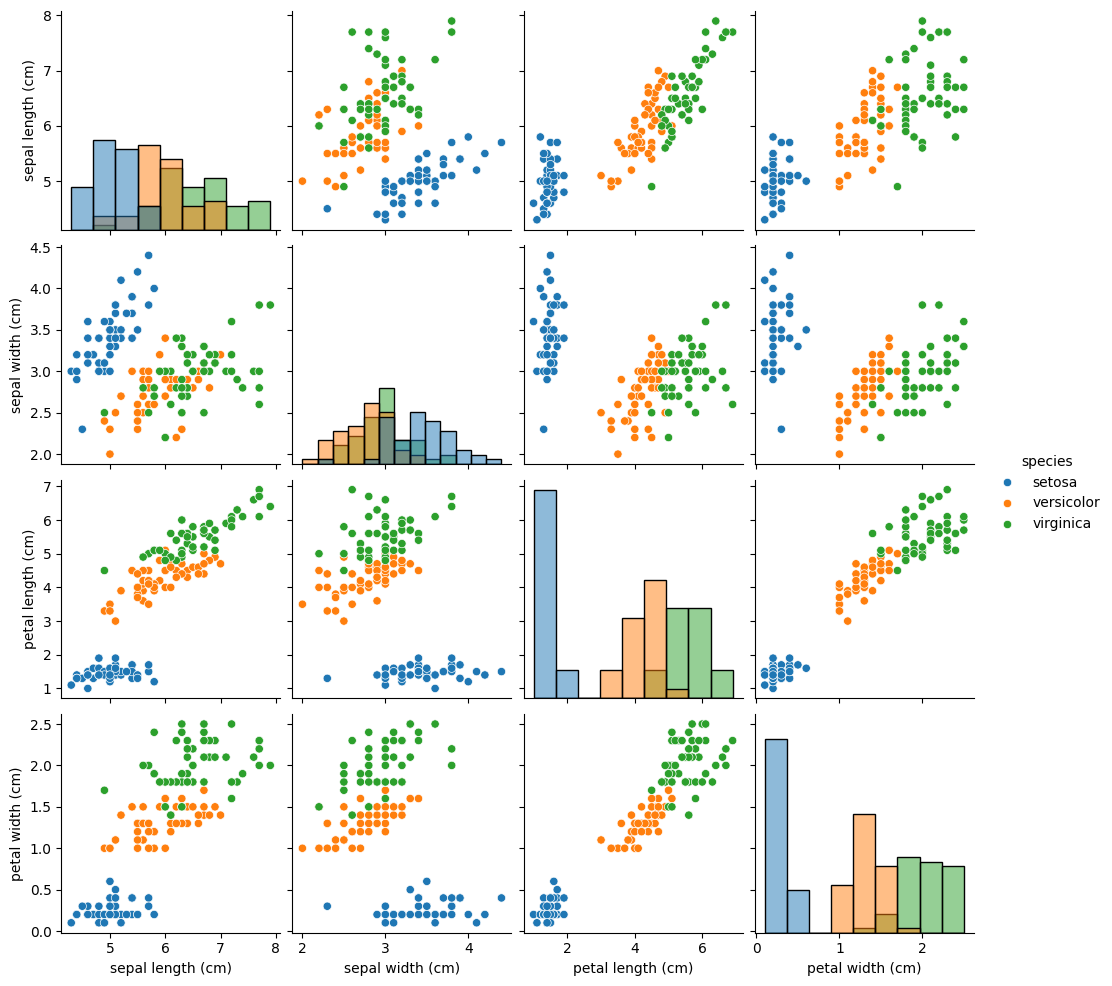

In [6]:
# Exercise #2: use sns.pairplot() to generate the pair-plots for the features in the dataset, again
# color data points according to their corresponding class

# Create a DataFrame for seaborn
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df['species'] = iris_df['species'].map({i: name for i, name in enumerate(iris.target_names)})

# Generate pairplot
sns.pairplot(iris_df, hue='species', diag_kind='hist')


In [7]:
# What are your main observations from exercise #2?

# Setosa forms a distinct cluster in almost every feature. It is clearly linearly separable from the other two classes.
# Versicolor and Virginica show overlap in several plots. Best Separation is visible in Petal Length vs Petal Width, and Petal Width vs Sepal Length

## PART 1: Decision Tree Classifier

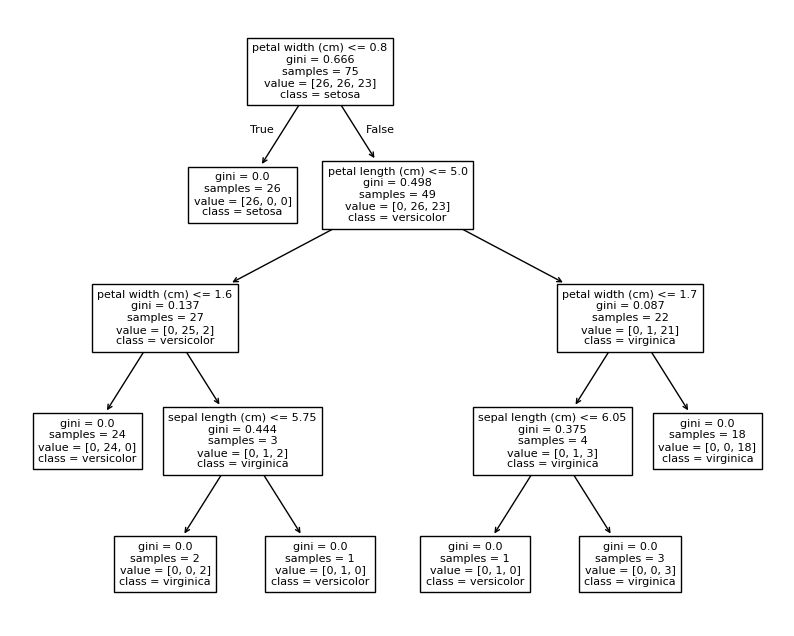

In [8]:
# Splits the data into two subsets of equal size (for training and testing purposes), trains a single 
# decision tree classifier, and displays the tree with the main node properties

trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)
dtc = DecisionTreeClassifier()
dtc.fit(trn_feat,trn_tgt)

fig,ax = plt.subplots(1,1,figsize=(10,8))
tree.plot_tree(dtc,fontsize=8,ax=ax,feature_names=iris.feature_names,class_names=iris.target_names)
plt.show()

In [9]:
# Exercise #3: use dtc.predict() and classification_report() to compute predictions and their
# corresponing scores for both the training and testing datasets

# For training set
ex3_train_pred = dtc.predict(trn_feat)
ex3_train_dict = classification_report(trn_tgt, ex3_train_pred, output_dict=True)
ex3_train_df = pd.DataFrame(ex3_train_dict).transpose()
print("Training Set Performance:")
print(ex3_train_df.round(3))

# For Testing Set
ex3_pred = dtc.predict(tst_feat)
ex3_dict = classification_report(tst_tgt, ex3_pred, output_dict=True)
report_df = pd.DataFrame(ex3_dict).transpose()
print(report_df.round(3))

Training Set Performance:
              precision  recall  f1-score  support
0                   1.0     1.0       1.0     26.0
1                   1.0     1.0       1.0     26.0
2                   1.0     1.0       1.0     23.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0     75.0
weighted avg        1.0     1.0       1.0     75.0
              precision  recall  f1-score  support
0                 1.000   1.000     1.000    24.00
1                 0.800   1.000     0.889    24.00
2                 1.000   0.778     0.875    27.00
accuracy          0.920   0.920     0.920     0.92
macro avg         0.933   0.926     0.921    75.00
weighted avg      0.936   0.920     0.919    75.00


In [10]:
# What are your main observations from exercise #3?
# Setosa is classified perfectly with precision, recall, and f1-score at 1
# Versicolor and Virginica show slighly lower accuracy but still is a very good result.
# Overfitting occurs

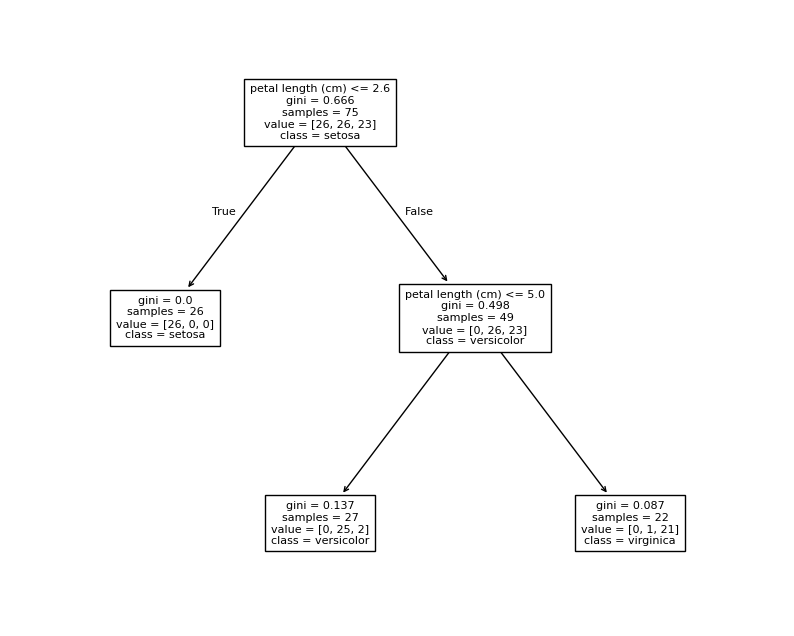

In [11]:
# Exercise #4: use the same data split from exercise #1 to train a new decision classifier but, this time,
# use the ccp_alpha parameter to conduct cost complexity pruning (i.e. weakest link pruning). Use alpha = 0.02

trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)
dtc = DecisionTreeClassifier(ccp_alpha=0.2)
dtc.fit(trn_feat,trn_tgt)

fig,ax = plt.subplots(1,1,figsize=(10,8))
tree.plot_tree(dtc,fontsize=8,ax=ax,feature_names=iris.feature_names,class_names=iris.target_names)
plt.show()


In [12]:
# What are your main observations? How the resulting tree compares to the previous one?
# This is a much simpler tree, only 3 leaf nodes

In [13]:
# Exercise #4 (continuation): use dtc.predict() and classification_report() to compute predictions with the
# new tree classifier and their corresponing scores for both the training and testing datasets 

# For training set
ex4_train_pred = dtc.predict(trn_feat)
ex4_train_dict = classification_report(trn_tgt, ex4_train_pred, output_dict=True)
ex4_train_df = pd.DataFrame(ex4_train_dict).transpose()
print("Training Set Performance:")
print(ex4_train_df.round(3))

# For Testing Set
ex4_pred = dtc.predict(tst_feat)
ex4_dict = classification_report(tst_tgt, ex4_pred, output_dict=True)
report_df = pd.DataFrame(ex4_dict).transpose()
print(report_df.round(3))


Training Set Performance:
              precision  recall  f1-score  support
0                 1.000   1.000     1.000    26.00
1                 0.926   0.962     0.943    26.00
2                 0.955   0.913     0.933    23.00
accuracy          0.960   0.960     0.960     0.96
macro avg         0.960   0.958     0.959    75.00
weighted avg      0.960   0.960     0.960    75.00
              precision  recall  f1-score  support
0                 1.000   1.000     1.000   24.000
1                 0.774   1.000     0.873   24.000
2                 1.000   0.741     0.851   27.000
accuracy          0.907   0.907     0.907    0.907
macro avg         0.925   0.914     0.908   75.000
weighted avg      0.928   0.907     0.906   75.000


In [14]:
# What are your main conclusions from exercise #4? How these results compare to the ones from exercise #3?
# We have improvement on Iris-Virginica prediction to 100% with the heavy trade-off of Versicolour, dropping from 80% to 77.4%
# Overfitting still occurs


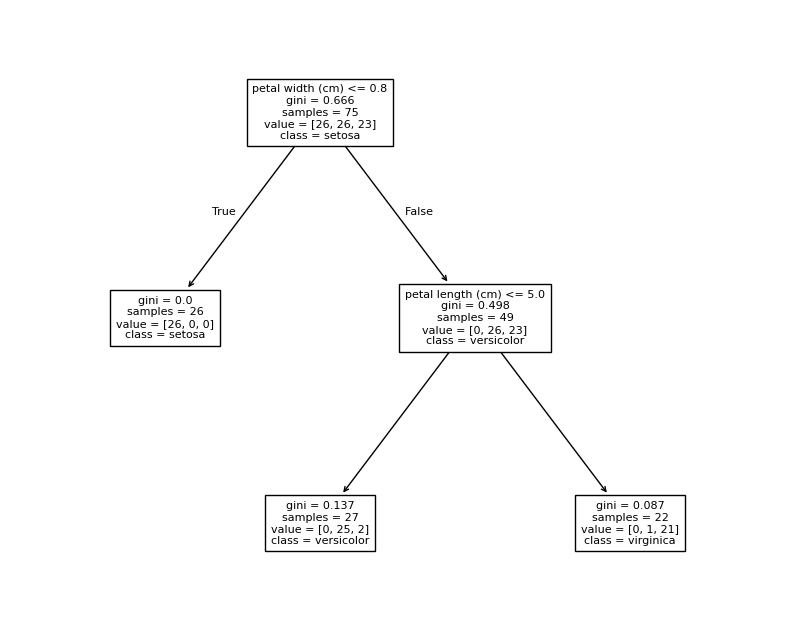

In [15]:
# Exercise #5: repeat exercise #4 but use alpha = 0.05 this time

trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)
dtc = DecisionTreeClassifier(ccp_alpha=0.05)
dtc.fit(trn_feat,trn_tgt)

fig,ax = plt.subplots(1,1,figsize=(10,8))
tree.plot_tree(dtc,fontsize=8,ax=ax,feature_names=iris.feature_names,class_names=iris.target_names)
plt.show()


In [16]:
# What are your main observations? How the resulting tree compares to the previous ones?
# Petal Length becomes the main feature instead of petal width, the height of the tree is the same as previous ones.

In [17]:
# Exercise #5 (continuation): use dtc.predict() and classification_report() to compute predictions with the
# new tree classifier and their corresponing scores for both the training and testing datasets  

# For training set
ex5_train_pred = dtc.predict(trn_feat)
ex5_train_dict = classification_report(trn_tgt, ex5_train_pred, output_dict=True)
ex5_train_df = pd.DataFrame(ex5_train_dict).transpose()
print("Training Set Performance:")
print(ex5_train_df.round(3))

# For Testing Set
ex5_pred = dtc.predict(tst_feat)
ex5_dict = classification_report(tst_tgt, ex5_pred, output_dict=True)
report_df = pd.DataFrame(ex5_dict).transpose()
print(report_df.round(3))


Training Set Performance:
              precision  recall  f1-score  support
0                 1.000   1.000     1.000    26.00
1                 0.926   0.962     0.943    26.00
2                 0.955   0.913     0.933    23.00
accuracy          0.960   0.960     0.960     0.96
macro avg         0.960   0.958     0.959    75.00
weighted avg      0.960   0.960     0.960    75.00
              precision  recall  f1-score  support
0                 1.000   1.000     1.000   24.000
1                 0.774   1.000     0.873   24.000
2                 1.000   0.741     0.851   27.000
accuracy          0.907   0.907     0.907    0.907
macro avg         0.925   0.914     0.908   75.000
weighted avg      0.928   0.907     0.906   75.000


In [18]:
# What are your main conclusions from exercise #5? How these results compare to the ones from exercises #3 and #4?
# It generates the same result as ex4. Reducing the alpha does not guarantee better accuracy.

## PART 2: Random Forest Classifier

In [26]:
# Exercise #6: use RandomForestClassifier() with parameterds n_estimators = 200 and random_state = 1 to 
# train a random forest ensemble and report the classification scores on both the training and testing 
# datasets (use the provided data partition)

trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)
rfc = RandomForestClassifier(n_estimators=200, random_state=1)
rfc.fit(trn_feat,trn_tgt)

# For training set
ex6_train_pred = dtc.predict(trn_feat)
ex6_train_dict = classification_report(trn_tgt, ex6_train_pred, output_dict=True)
ex6_train_df = pd.DataFrame(ex6_train_dict).transpose()
print("Training Set Performance:")
print(ex6_train_df.round(3))

# For Testing Set
ex6_pred = rfc.predict(tst_feat)
ex6_dict = classification_report(tst_tgt, ex6_pred, output_dict=True)
report_df = pd.DataFrame(ex6_dict).transpose()
print(report_df.round(3))


Training Set Performance:
              precision  recall  f1-score  support
0                 1.000   1.000     1.000    26.00
1                 0.926   0.962     0.943    26.00
2                 0.955   0.913     0.933    23.00
accuracy          0.960   0.960     0.960     0.96
macro avg         0.960   0.958     0.959    75.00
weighted avg      0.960   0.960     0.960    75.00
              precision  recall  f1-score  support
0                 1.000   1.000     1.000   24.000
1                 0.885   0.958     0.920   24.000
2                 0.960   0.889     0.923   27.000
accuracy          0.947   0.947     0.947    0.947
macro avg         0.948   0.949     0.948   75.000
weighted avg      0.949   0.947     0.947   75.000


In [ ]:
# What are your main observations from exercise #6?
# Overfitting still occurs. But this is the best result so far with the accuracy 96% for the training dataset and 94% for testing dataset

In [27]:
# Exercise #7: use GridSearchCV() to conduct parameter fine-tuning with cross-validation, use KFold() to set
# up a cross-validation experiment with n_splits = 2 (consider the provided parameter grid for your experiment).
# Display the obtained optimal values for 'ccp_alpha', 'max_depth', 'max_features' and 'n_estimators' (use
# also random_state = 1)

rfc_param = {'ccp_alpha':[0.03,0.05],'max_depth':[8,9,10], 'max_features':[1,2], 'n_estimators':[200,300]}


# Set up 2-fold cross-validation
kfold = KFold(n_splits=2, shuffle=True, random_state=1)

# Create Random Forest model
rfc = RandomForestClassifier(random_state=1)

# Set up GridSearchCV
grid = GridSearchCV(
    estimator=rfc,
    param_grid=rfc_param,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the model
grid.fit(trn_feat, trn_tgt)

# Show best parameters
print("Best Parameters:")
for param in ['ccp_alpha', 'max_depth', 'max_features', 'n_estimators']:
    print(f"  {param}: {grid.best_params_[param]}")


Best Parameters:
  ccp_alpha: 0.03
  max_depth: 8
  max_features: 2
  n_estimators: 300


In [ ]:
# What are your main observations from exercise #7?
# Choosing the best params with the best values are key for a good model.

In [29]:
# Exercise #7 (continuation): use the optimal parameter values obtained in the previous cell to train a new
# RandomForestClassifier(), compute predictions and display scores for both training and testing datasets
# (keep using random_state = 1)

rfc_best = RandomForestClassifier(
    ccp_alpha=grid.best_params_['ccp_alpha'],
    max_depth=grid.best_params_['max_depth'],
    max_features=grid.best_params_['max_features'],
    n_estimators=grid.best_params_['n_estimators'],
    random_state=1
)

# Fit the model
rfc_best.fit(trn_feat, trn_tgt)

# === Evaluate on Training Set ===
train_pred = rfc_best.predict(trn_feat)
train_report = classification_report(trn_tgt, train_pred, output_dict=True)
train_df = pd.DataFrame(train_report).transpose()
print("Training Set Performance:")
print(train_df.round(3))

# === Evaluate on Testing Set ===
test_pred = rfc_best.predict(tst_feat)
test_report = classification_report(tst_tgt, test_pred, output_dict=True)
test_df = pd.DataFrame(test_report).transpose()
print("\nTesting Set Performance:")
print(test_df.round(3))


Training Set Performance:
              precision  recall  f1-score  support
0                 1.000   1.000     1.000   26.000
1                 1.000   0.962     0.980   26.000
2                 0.958   1.000     0.979   23.000
accuracy          0.987   0.987     0.987    0.987
macro avg         0.986   0.987     0.986   75.000
weighted avg      0.987   0.987     0.987   75.000

Testing Set Performance:
              precision  recall  f1-score  support
0                 1.000   1.000     1.000   24.000
1                 0.885   0.958     0.920   24.000
2                 0.960   0.889     0.923   27.000
accuracy          0.947   0.947     0.947    0.947
macro avg         0.948   0.949     0.948   75.000
weighted avg      0.949   0.947     0.947   75.000


In [ ]:
# What are your main observations from exercise #7? How these results compare with those from exercise #6?
# This is indeed the best model using RFC. The result is 95%, which is a sufficient threshold for a performing model.


## PART 3: Gradient Boosting Classifier

In [35]:
# Exercise #8: use GradientBoostingClassifier() with parameterds n_estimators = 10 and random_state = 1 to 
# train a boosting ensemble and report the classification scores on both the training and testing datasets
# (use the provided data partition)

trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)

gbc = GradientBoostingClassifier(n_estimators=10, random_state=1)
gbc.fit(trn_feat,trn_tgt)

# For training set
ex8_train_pred = gbc.predict(trn_feat)
ex8_train_dict = classification_report(trn_tgt, ex8_train_pred, output_dict=True)
ex8_train_df = pd.DataFrame(ex8_train_dict).transpose()
print("Training Set Performance:")
print(ex8_train_df.round(3))

# For Testing Set
ex8_pred = gbc.predict(tst_feat)
ex8_dict = classification_report(tst_tgt, ex8_pred, output_dict=True)
report_df = pd.DataFrame(ex8_dict).transpose()
print(report_df.round(3))


Training Set Performance:
              precision  recall  f1-score  support
0                   1.0     1.0       1.0     26.0
1                   1.0     1.0       1.0     26.0
2                   1.0     1.0       1.0     23.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0     75.0
weighted avg        1.0     1.0       1.0     75.0
              precision  recall  f1-score  support
0                 1.000   1.000     1.000    24.00
1                 0.889   1.000     0.941    24.00
2                 1.000   0.889     0.941    27.00
accuracy          0.960   0.960     0.960     0.96
macro avg         0.963   0.963     0.961    75.00
weighted avg      0.964   0.960     0.960    75.00


In [ ]:
# What are your main observations from exercise #8?
# Training Set Performance is 100%, which is sign of memorizing the data. Accuracy is 96% for the Testing Set.
# Recall and f1 are high.
# Overfitting occurs

In [45]:
# Exercise #9: use GridSearchCV() to conduct parameter fine-tuning with cross-validation, use KFold() to set
# up a cross-validation experiment with n_splits = 2 (consider the provided parameter grid for your experiment).
# Display the obtained optimal values for 'ccp_alpha', 'learning_rate', 'max_depth' and 'n_estimators' (use
# also random_state = 1)

gbc_param = {'ccp_alpha':[0.01,0.03,0.05], 'learning_rate':[0.005,0.007,0.01], 'max_depth':[1,2,3], 'n_estimators':[10,20,30]}


# Set up 2-fold cross-validation
kfold = KFold(n_splits=2, shuffle=True, random_state=1)

# Create Random Forest model
gbc = GradientBoostingClassifier(random_state=1)

# Set up GridSearchCV
grid = GridSearchCV(
    estimator=gbc,
    param_grid=gbc_param,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the model
grid.fit(trn_feat, trn_tgt)

# Show best parameters
print("Best Parameters:")
for param in ['ccp_alpha', 'learning_rate', 'max_depth', 'n_estimators']:
    print(f"  {param}: {grid.best_params_[param]}")


Best Parameters:
  ccp_alpha: 0.05
  learning_rate: 0.01
  max_depth: 3
  n_estimators: 30


In [ ]:
# What are your main observations from exercise #9?
# The higher value of the parameter, the better result it gains.

In [49]:
# Exercise #9 (continuation): use the optimal parameter values obtained in the previous cell to train a new
# GradientBoostingClassifier(), compute predictions and display scores for both training and testing datasets
# (keep using random_state = 1)


trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)

gbc = GradientBoostingClassifier(n_estimators=grid.best_params_['n_estimators'],
                                  ccp_alpha=grid.best_params_['ccp_alpha'],
                                    learning_rate=grid.best_params_['learning_rate'],
                                      max_depth=grid.best_params_['max_depth'],
                                        random_state=1)
gbc.fit(trn_feat,trn_tgt)

# For training set
ex9_train_pred = gbc.predict(trn_feat)
ex9_train_dict = classification_report(trn_tgt, ex9_train_pred, output_dict=True)
ex9_train_df = pd.DataFrame(ex9_train_dict).transpose()
print("Training Set Performance:")
print(ex9_train_df.round(3))

# For Testing Set
ex9_pred = gbc.predict(tst_feat)
ex9_dict = classification_report(tst_tgt, ex9_pred, output_dict=True)
ex9_report_df = pd.DataFrame(ex9_dict).transpose()
print(ex9_report_df.round(3))



Training Set Performance:
              precision  recall  f1-score  support
0                 1.000   1.000     1.000    26.00
1                 0.926   0.962     0.943    26.00
2                 0.955   0.913     0.933    23.00
accuracy          0.960   0.960     0.960     0.96
macro avg         0.960   0.958     0.959    75.00
weighted avg      0.960   0.960     0.960    75.00
              precision  recall  f1-score  support
0                 1.000   1.000     1.000   24.000
1                 0.774   1.000     0.873   24.000
2                 1.000   0.741     0.851   27.000
accuracy          0.907   0.907     0.907    0.907
macro avg         0.925   0.914     0.908   75.000
weighted avg      0.928   0.907     0.906   75.000


In [ ]:
# What are your main observations from exercise #9? How these results compare with those from exercise #8?
# When combine all optimal params, the model does not yield the best result.
# The model has lower accuracy (91%) compared to #8 96%.